In [1]:
import sys
import importlib
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import torch
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, f1_score, precision_recall_fscore_support, classification_report
from sklearn.utils import class_weight
from keras.utils import to_categorical 
import tensorflow as tf
from tqdm.keras import TqdmCallback

sys.path.insert(0, '/lustre/lrspec/users/4301/hxe-for-tda/hxetda/')
import hxetda

sys.path.insert(0, "/lustre/lrspec/users/4301/ABC-SN/code")
import data_degrading as dg
import abcsn_training
import abcsn_config
import data_preparation as dp
import preprocessing as pp

sys.path.insert(0, "/lustre/lrspec/users/4301/Milligan_ABC-SN/")
from plot_data import *
from process_data import *
import heir_loss

2026-08-12 11:11:52.317500: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
/home/4301/miniconda3/envs/tf-gpu/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import tensorflow as tf

# Get the build information dictionary
build_info = tf.sysconfig.get_build_info()

# Print the CUDA version it was built for
print("CUDA Version TensorFlow was built with:", build_info.get('cuda_version', 'Not found'))
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

CUDA Version TensorFlow was built with: 12.5.1
Num GPUs Available:  1


In [3]:
file = "/lustre/lrspec/users/4301/Milligan_ABC-SN/data/full_preprocessed_dataframe.parquet"
master_df = pd.read_parquet(file)

data = dp.extract_dataframe(master_df)

wvl = data[1]  # Wavelength array
flux0_columns = data[2]  # Columns that index the fluxes in the dataframe
metadata = data[5]  # Sub-dataframe containing only the metadata
all_features = data[6]  # Only the flux values in a numpy array
fluxes0 = data[6]  # Only the flux values in a numpy array

labels = metadata.sn_type

In [4]:
vertices =  np.asarray(np.unique(labels),dtype=str)
vertices

array(['CaRT', 'II', 'IIb', 'IIn', 'Ia', 'Iap', 'Ib', 'Ic', 'SL', 'TDE'],
      dtype='<U4')

# Set up heirarchy

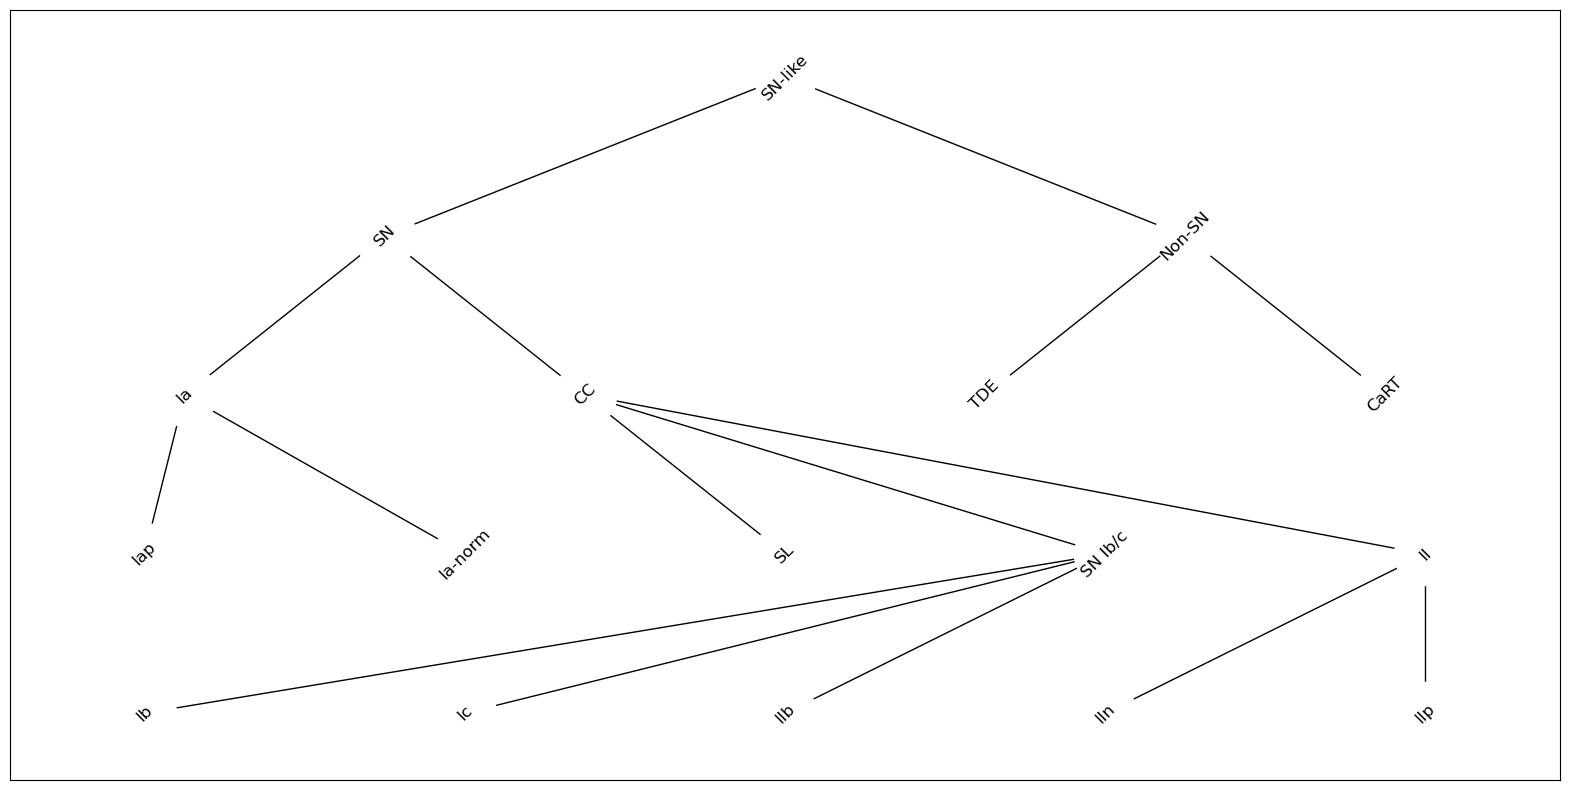

In [5]:
# Make a graph

G=nx.DiGraph()

G.add_edge('SN-like', 'SN')

G.add_edge('SN-like', 'Non-SN') 

# non-SN Transients
G.add_edge('Non-SN', 'TDE')
G.add_edge('Non-SN', 'CaRT')

# SN Ia
G.add_edge('SN', 'Ia')
G.add_edge('Ia', 'Iap')
G.add_edge('Ia', 'Ia-norm')


# CC SN
G.add_edge('SN', 'CC')
G.add_edge('CC', 'SL')


## SN Ib/c
G.add_edge('CC', 'SN Ib/c')
G.add_edge('SN Ib/c', 'Ib')
G.add_edge('SN Ib/c', 'Ic')
G.add_edge('SN Ib/c', 'IIb')  # do under stripped envelope

## SN II
G.add_edge('CC', 'II')
# G.add_edge('CC', 'IIn') # not sure why this is separate from SN II 
G.add_edge('II', 'IIn')
G.add_edge('II', 'IIp') # this is essentially normal "plateau"

importlib.reload(hxetda)
pos = hxetda.hierarchy_pos(G, 'SN-like')

fig = plt.figure(1, figsize=(20, 10))

nx.draw_networkx(G, pos=pos, node_color='white', with_labels=False, node_size=2000, arrows=False)
text = nx.draw_networkx_labels(G, pos)
for _, t in text.items():
    t.set_rotation(45) 

plt.show()

# Load data + preprocessing (hxe-tda)
### for my current code all only need pathlengths, masklist, y_dict, and weights(?)

In [6]:
conversions = {'Ia':'Ia-norm',
                'II':'IIp' # i think this is fine
                }

In [7]:
# Let's import preprocess our variable star data
scaler = StandardScaler()

def make_dataset(load=False):
    data = dp.extract_dataframe(master_df)
    
    metadata = data[5]  # Sub-dataframe containing only the metadata
    flux0_columns = data[2]  # Columns that index the fluxes in the dataframe
    all_labels = metadata.sn_type.values
    vertices =  np.asarray(np.unique(all_labels),dtype=str)
    all_flux = data[6] 

    for key in conversions:
        gind = np.where(all_labels == key)
        if len(gind[0])==0:
            print(f"no labels: {key}")
        else:
            all_labels[gind] = conversions[key]
    
    vertices = np.asarray(np.unique(all_labels),dtype=str)
    print(np.unique(all_labels, return_counts=True))
    vertices = np.append(vertices, ['Non-SN', 'SN', 'CC', "SN Ib/c", "Ia", "II"])
    vertices = np.insert(vertices, 0, 'SN-like')

    return(all_labels, vertices)

labels, vertices = make_dataset()
scaler.fit(all_features)
all_features = scaler.transform(all_features)

(array(['CaRT', 'IIb', 'IIn', 'IIp', 'Ia-norm', 'Iap', 'Ib', 'Ic', 'SL',
       'TDE'], dtype=object), array([  52,  542,  880, 1819, 8074,  263,  262,  193, 1262,   96]))


In [8]:
# classification leaves 
leaves = np.asarray(['CaRT', 'IIb', 'IIn', 'IIp', 'Ia-norm', 'Iap', 'Ib', 'Ic', 'SL','TDE'], dtype=str)

In [9]:
# Some pre-processing for the graph
paths, pathlengths, mask_list, y_dict = hxetda.calc_path_and_mask(G, vertices, 'SN-like')

In [10]:
# mask_list shows the number of options in various parent groups
mask_list

[tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0]),
 tensor([0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0]),
 tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0]),
 tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1]),
 tensor([0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0]),
 tensor([0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]),
 tensor([0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])]

# Set up training and model

In [11]:
# Set up for train test split...
index = master_df.index.values
y_mhe = np.array([y_dict[x] for x in labels]) # "multi hot encoding"
X = fluxes0.copy()
X = X.reshape(X.shape[0],1,X.shape[1])

# Getting index of the train test split
train_index, test_index = train_test_split(index, test_size = 0.3, random_state = 7, stratify = labels)

# splitting all the inputs
X_train = X[train_index]
X_test = X[test_index]

y_train = y_mhe[train_index]
y_test = y_mhe[test_index]

labels_test = labels[test_index]

In [12]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((9410, 1, 139), (4033, 1, 139), (9410, 17), (4033, 17))

# Class weights

In [13]:
# Some pre-processing for the hxetda class weights
class_weight_hxetda_dict = hxetda.calc_class_weights(labels, vertices, paths)
class_weight_hxetda_dict

weights = np.array([class_weight_hxetda_dict[x] for x in labels])
weights_train = weights[train_index]
weights_test = weights[test_index]

In [14]:
my_class_weights = heir_loss.class_weights_hxetda(y_mhe)
len(my_class_weights) == len(vertices)
for i in range(len(vertices)):
    print(f"{vertices[i]} : {my_class_weights[i]:.3}")

SN-like : 0.251
CaRT : 64.8
IIb : 6.22
IIn : 3.83
IIp : 1.85
Ia-norm : 0.418
Iap : 12.8
Ib : 12.9
Ic : 17.5
SL : 2.67
TDE : 35.1
Non-SN : 22.8
SN : 0.254
CC : 0.68
SN Ib/c : 3.38
Ia : 0.404
II : 1.25


## Loss function

In [15]:
mask_list = np.array(mask_list)
pathlengths = np.array(pathlengths)


/tmp/ipykernel_38576/971335581.py:2: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  pathlengths = np.array(pathlengths)


In [16]:
# version with my weights 
loss_fn = heir_loss.WeightedHierchicalLoss_hxetda(mask_list, pathlengths, class_weights=my_class_weights, alpha=0.5)

## Add Callbacks

In [17]:
# early stopping 
early_stop = keras.callbacks.EarlyStopping(
        monitor="val_loss",
        # min_delta=1e-2, # stated during meeting (note higher than willows)
        min_delta=1e-3, 
        patience= 25, # stated in meeting + same as willows
        verbose=2,
        mode="min",
        restore_best_weights=True 
        )

# model_filepath = "/lustre/lrspec/users/4301/Milligan_ABC-SN/models/model_checkpoint{epoch}.keras" # this one creates many files
model_filepath = "/lustre/lrspec/users/4301/Milligan_ABC-SN/models/model_checkpoint_weighted_loss.keras"
model_checkpoints = keras.callbacks.ModelCheckpoint(
    model_filepath,
    monitor="val_loss",
    verbose=0,
    save_freq = 10,
    mode="min",
    save_best_only=True
    )

epoch_bound = 100
batch_size = 64 # used below
step_bound = len(train_index) * epoch_bound // batch_size

learning_rate_schedule = tf.keras.optimizers.schedules.PiecewiseConstantDecay(
    boundaries=[step_bound],  # Epoch when the change happens
    values=[1e-5, 2e-6]  # Learning rates: [before boundary, after boundary]
    )

## Add New Layer to Model

In [18]:
# Loading model 
abcsn = keras.models.load_model("/lustre/lrspec/users/4301/ABC-SN/abcsn/ABCSN.keras", compile=False)

I0000 00:00:1786547520.304507   38576 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13762 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:81:00.0, compute capability: 7.5


In [19]:
# Fine-tune from this layer onwards
fine_tune_at = len(abcsn.layers)-8

# Freeze all the layers before the `fine_tune_at` layer
for layer in abcsn.layers[:fine_tune_at]:
    layer.trainable = False

In [20]:
new_model = keras.Model(
    inputs=abcsn.input, 
    outputs=abcsn.layers[-2].output)

from tensorflow.keras import layers

new_output = layers.Dense(17, activation="softmax", name="heirarchical_dense")(new_model.output)
heir_abcsn = keras.Model(inputs=new_model.input, outputs=new_output)

In [21]:
heir_abcsn.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 1, 139)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 1, 1024)   │    143,360 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_2 (Reshape) │ (None, 64, 16)    │          0 │ dense_5[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 64, 128)   │      2,176 │ reshape_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sine_position_enco… │ (None, 64, 128)   │          0 │ dense_6[0][0]     │
│ (SinePositionEncod… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 64, 64)    │      8,256 │ sine_position_en… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 64, 128)   │      8,320 │ dense_7[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 64, 128)   │          0 │ dense_6[0][0],    │
│                     │                   │            │ dense_8[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_encode… │ (None, 64, 128)   │     83,136 │ add_1[0][0]       │
│ (TransformerEncode… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_encode… │ (None, 64, 128)   │     83,136 │ transformer_enco… │
│ (TransformerEncode… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_encode… │ (None, 64, 128)   │     83,136 │ transformer_enco… │
│ (TransformerEncode… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_encode… │ (None, 64, 128)   │     83,136 │ transformer_enco… │
│ (TransformerEncode… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_encode… │ (None, 64, 128)   │     83,136 │ transformer_enco… │
│ (TransformerEncode… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_encode… │ (None, 64, 128)   │     83,136 │ transformer_enco… │
│ (TransformerEncode… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 8192)      │          0 │ transformer_enco… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_9 (Dense)     │ (None, 1024)      │  8,389,632 │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_12          │ (None, 1024)      │          0 │ dense_9[0][0]     │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_10 (Dense)    │ (None, 256)       │    262,400 │ dropout_12[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_13          │ (None, 256)       │          0 │ dense_10[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 9,330,513 (35.59 MB)

 Trainable params: 8,669,585 (33.07 MB)

 Non-trainable params: 660,928 (2.52 MB)

In [22]:
len(heir_abcsn.trainable_variables)

8

## Compile Model

In [23]:
acc = keras.metrics.CategoricalAccuracy(name="ca")
f1 = keras.metrics.F1Score(average="macro", name="f1")
optimizer = keras.optimizers.Nadam(learning_rate=learning_rate_schedule)

# Compile your model
heir_abcsn.compile(
    loss=loss_fn,
    optimizer=optimizer,
    metrics=[acc, f1]
)



# Train

In [24]:
# weights are implemented incorrectly
history = heir_abcsn.fit(X_train, y_train, 
                    # sample_weight=weights_train,
                    validation_data= (X_test, y_test), 
                    epochs = 800,    # choosen arbitrarily 
                    batch_size = 64, # same as willow used
                    verbose= 0,
                    callbacks=[model_checkpoints, early_stop, TqdmCallback(verbose=0)],
                   )

  0%|          | 0/800 [00:00<?, ?epoch/s]2026-08-12 11:12:02.192824: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}
/home/4301/miniconda3/envs/tf-gpu/lib/python3.10/site-packages/keras/src/callbacks/model_checkpoint.py:276: UserWarning: Can save best model only with val_loss available.
  if self._should_save_model(epoch, batch, logs, filepath):
2026-08-12 11:12:19.4

Epoch 332: early stopping
Restoring model weights from the end of the best epoch: 307.


 42%|████▏     | 332/800 [56:22<1:19:28, 10.19s/epoch, ca=0, f1=0.0587, loss=0.874, val_ca=0, val_f1=0.0555, val_loss=0.886]


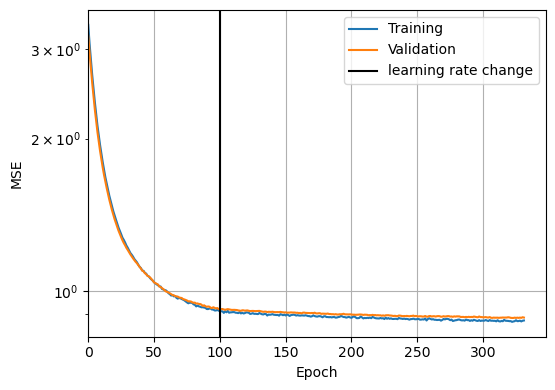

In [25]:
log = history.history
abcsn_training.plot_loss(log, scale=4, cb_es=None, patience_es=None)
plt.axvline(epoch_bound, label= "learning rate change", color = 'k')
# plt.axvline(485, label= "best epoch", color = 'g')
plt.legend()
# plt.ylim(4,5)

In [26]:
model_name = "heirarchical_model_my_weight"
heir_abcsn.save(f"/lustre/lrspec/users/4301/Milligan_ABC-SN/model_results/{model_name}.keras")
(pd.DataFrame(log)).to_csv(f"/lustre/lrspec/users/4301/Milligan_ABC-SN/model_results/{model_name}.csv")

In [27]:
df_test = master_df.iloc[test_index].copy()

# Load and Plot Model Results

In [28]:
heir_abcsn = keras.models.load_model(f"/lustre/lrspec/users/4301/Milligan_ABC-SN/model_results/heirarchical_model.keras", compile=False)

In [29]:
P = heir_abcsn.predict(X_test, verbose=0)

2026-08-12 12:08:26.634847: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


In [30]:
mask_list

array([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0],
       [0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1],
       [0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]])

In [31]:
# get probabilities of a subset of labels 

leaves_wanted = np.asarray(['Ia', 'SN Ib/c', 'II', 'SL', 'Non-SN'], dtype=str)
probs_list = np.zeros((len(P), len(leaves_wanted)))
probs_true = np.zeros((len(P), len(leaves_wanted)))
y_pred_tensor = torch.Tensor(P)
mask_list_tensor = torch.Tensor(mask_list)

for i,leaf in enumerate(leaves_wanted):
    probs_list[:,i] = hxetda.get_prob(y_pred_tensor,leaf, paths, vertices, mask_list_tensor).detach().numpy()
    probs_true[:,i] = hxetda.get_prob(torch.Tensor(y_test),leaf, paths, vertices, mask_list_tensor).detach().numpy()

P_argmax = np.argmax(probs_list, axis=1)
np.unique(P_argmax, return_counts = True) # yikes

(array([0]), array([4033]))

In [32]:
# get true matrix 
y_matrix_true = np.zeros((len(P), len(leaves_wanted)))

for i,leaf in enumerate(leaves_wanted):
    col = np.where(vertices == leaf)[0][0]
    y_matrix_true[:,i] = y_test[:,col]

y_true = np.argmax(y_matrix_true, axis=1)
np.unique(y_true, return_counts = True)

(array([0, 1, 2, 3, 4]), array([2501,  299,  810,  379,   44]))

In [33]:
cr = (classification_report(
    y_true,
    P_argmax,
    target_names=leaves_wanted))

print(cr) # yikes again 

              precision    recall  f1-score   support

          Ia       0.62      1.00      0.77      2501
     SN Ib/c       0.00      0.00      0.00       299
          II       0.00      0.00      0.00       810
          SL       0.00      0.00      0.00       379
      Non-SN       0.00      0.00      0.00        44

    accuracy                           0.62      4033
   macro avg       0.12      0.20      0.15      4033
weighted avg       0.38      0.62      0.47      4033



/home/4301/miniconda3/envs/tf-gpu/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/4301/miniconda3/envs/tf-gpu/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/4301/miniconda3/envs/tf-gpu/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()

In [34]:
y_true

array([0, 0, 0, ..., 2, 2, 0], shape=(4033,))

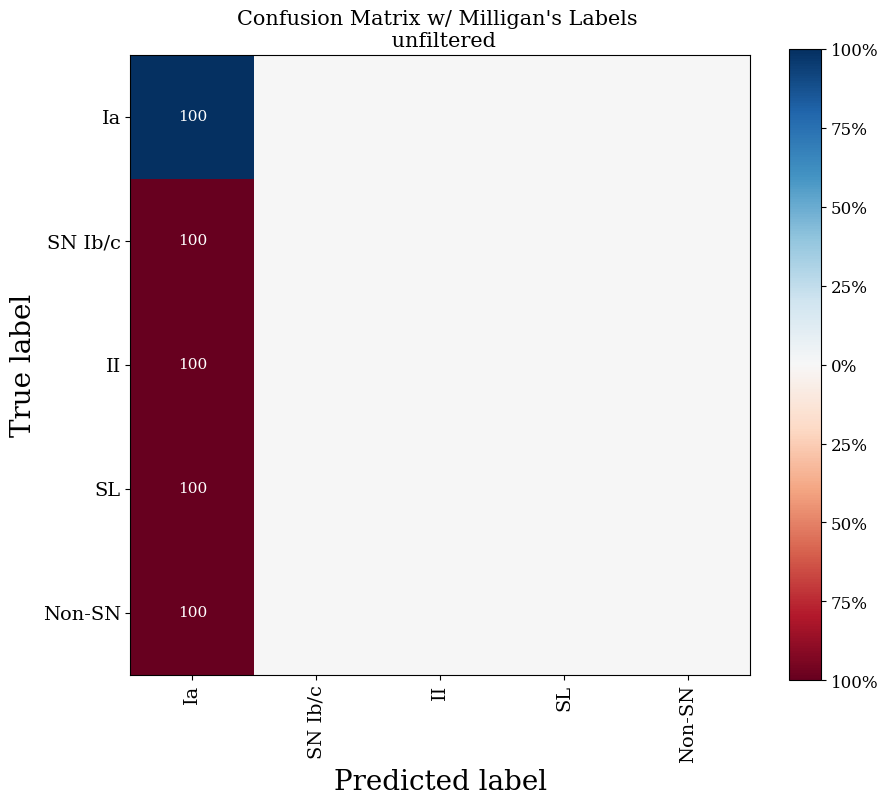

In [35]:
cm_mill = confusion_matrix(y_true, P_argmax)
plot = plot_cm(cm_mill, leaves_wanted, 
        title = "Confusion Matrix w/ Milligan's Labels \n unfiltered")

# looking at single probability 

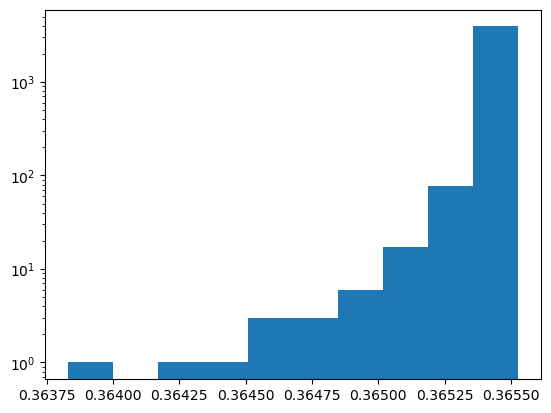

In [36]:
specific_class = 'Ia'
single_class_prob = hxetda.get_prob(y_pred_tensor,specific_class, paths, vertices, mask_list_tensor).detach().numpy()
plt.hist(single_class_prob)
plt.yscale('log')

In [37]:
# # 5-way task...
# # Get my leaves...
# importlib.reload(hxetda)

# leaves = np.asarray(['SN Ia','SN Ib/c', 'SN II', 'SLSN-I', 'SN IIn'], dtype=str)
# probs_list = np.zeros((len(y_pred), len(leaves)))
# for i,leaf in enumerate(leaves):
#     probs_list[:,i] = hxetda.get_prob(y_pred,leaf, paths, vertices, mask_list).detach().numpy()

# my_predicted_types = leaves[np.argmax(probs_list,axis=1)]

# fiveleaf_labels_test = np.copy(labels_test)

# for i,s in enumerate(fiveleaf_labels_test):
#     is_Ibc = hxetda.is_parent(s, 'SN Ib/c', vertices, paths)
#     if is_Ibc:
#         fiveleaf_labels_test[i] = 'SN Ib/c'

# gind = np.where(np.in1d(fiveleaf_labels_test,leaves))[0]
# cm = confusion_matrix(fiveleaf_labels_test[gind], my_predicted_types[gind], labels=leaves)
# disp = ConfusionMatrixDisplay(cm, display_labels=leaves)
# fig, ax = plt.subplots(figsize=(10,10))
# disp.plot(xticks_rotation='vertical', ax=ax)
# print(len(gind))
# print(leaves)
# print(labels_test[gind][9], probs_list[gind][9])

# print(precision_recall_fscore_support(fiveleaf_labels_test[gind], my_predicted_types[gind],average='macro'))
# print(precision_recall_fscore_support(fiveleaf_labels_test[gind], my_predicted_types[gind],average='micro'))